In [1]:
import tpqoa

In [2]:
api = tpqoa.tpqoa('pyalgo.cfg')

In [3]:
api.get_instruments()[:15]

[('AUD/CAD', 'AUD_CAD'),
 ('AUD/CHF', 'AUD_CHF'),
 ('AUD/HKD', 'AUD_HKD'),
 ('AUD/JPY', 'AUD_JPY'),
 ('AUD/NZD', 'AUD_NZD'),
 ('AUD/SGD', 'AUD_SGD'),
 ('AUD/USD', 'AUD_USD'),
 ('CAD/CHF', 'CAD_CHF'),
 ('CAD/HKD', 'CAD_HKD'),
 ('CAD/JPY', 'CAD_JPY'),
 ('CAD/SGD', 'CAD_SGD'),
 ('CHF/HKD', 'CHF_HKD'),
 ('CHF/JPY', 'CHF_JPY'),
 ('CHF/ZAR', 'CHF_ZAR'),
 ('EUR/AUD', 'EUR_AUD')]

In [4]:
help(api.get_history)

Help on method get_history in module tpqoa.tpqoa:

get_history(instrument, start, end, granularity, price, localize=True) method of tpqoa.tpqoa.tpqoa instance
    Retrieves historical data for instrument.

    Parameters
    instrument: string
        valid instrument name
    start, end: datetime, str
        Python datetime or string objects for start and end
    granularity: string
        a string like 'S5', 'M1' or 'D'
    price: string
        one of 'A' (ask), 'B' (bid) or 'M' (middle)

    Returns
    data: pd.DataFrame
        pandas DataFrame object with data



In [5]:
instrument = 'EUR_USD'
start = '2020-08-10'
end = '2020-08-12'
granularity = 'M1'
price = 'M'

In [6]:
data = api.get_history(instrument, start, end, granularity, price)

In [7]:
data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2814 entries, 2020-08-10 00:00:00 to 2020-08-11 23:59:00
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   o         2814 non-null   float64
 1   h         2814 non-null   float64
 2   l         2814 non-null   float64
 3   c         2814 non-null   float64
 4   volume    2814 non-null   int64  
 5   complete  2814 non-null   bool   
dtypes: bool(1), float64(4), int64(1)
memory usage: 134.7 KB


In [8]:
data[['c', 'volume']].head()

,c,volume
time,,
2020-08-10 00:00:00,1.17822,18
2020-08-10 00:01:00,1.17836,32
2020-08-10 00:02:00,1.17828,25
2020-08-10 00:03:00,1.17834,13
2020-08-10 00:04:00,1.17847,43


In [9]:
import numpy as np
data['returns'] = np.log(data['c'] / data['c'].shift(1))
cols = []
for momentum in [15, 30, 60, 120]:
    col = 'position_{}'.format(momentum)
    data[col]  = np.sign(data['returns'].rolling(momentum).mean())
    cols.append(col)


In [10]:
data.tail()

,o,h,l,c,volume,complete,returns,position_15,position_30,position_60,position_120
time,,,,,,,,,,,
2020-08-11 23:55:00,1.17364,1.17371,1.17361,1.17366,22,True,0.000026,-1.0,1.0,-1.0,-1.0
2020-08-11 23:56:00,1.17364,1.17364,1.17361,1.17364,9,True,-0.000017,-1.0,1.0,-1.0,-1.0
2020-08-11 23:57:00,1.17365,1.17366,1.17356,1.17357,11,True,-0.000060,-1.0,-1.0,-1.0,-1.0
2020-08-11 23:58:00,1.17358,1.17365,1.17358,1.17365,13,True,0.000068,-1.0,1.0,-1.0,-1.0
2020-08-11 23:59:00,1.17363,1.17369,1.17350,1.17350,20,True,-0.000128,-1.0,-1.0,-1.0,-1.0


In [11]:
from pylab import plt
plt.style.use('seaborn-v0_8')
import matplotlib as mpl
mpl.rcParams['savefig.dpi'] = 300
mpl.rcParams['font.family'] = 'serif'


<Axes: xlabel='time'>

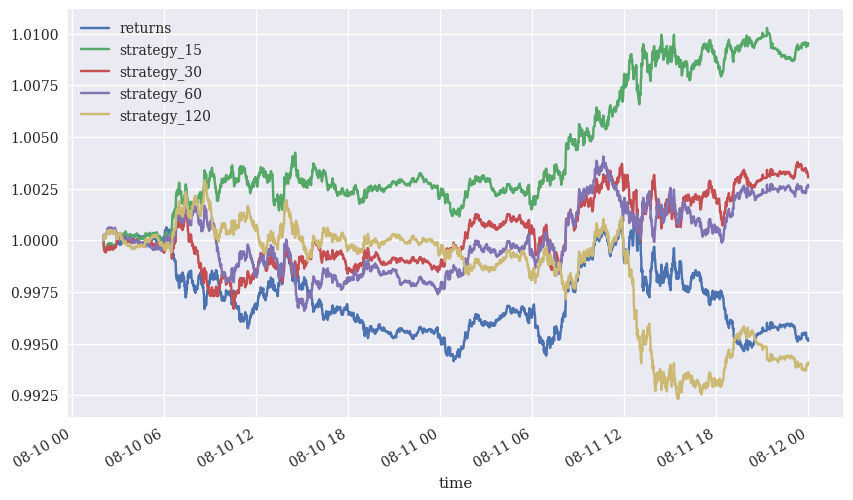

In [12]:
strats = ['returns']
for col  in cols:
    strat = 'strategy_{}'.format(col.split('_')[1])
    data[strat] = data[col].shift(1) * data['returns']
    strats.append(strat)
data[strats].dropna().cumsum(
    ).apply(np.exp).plot(figsize=(10,6))


In [13]:
data[strats].tail()

,returns,strategy_15,strategy_30,strategy_60,strategy_120
time,,,,,
2020-08-11 23:55:00,0.000026,-0.000026,-0.000026,-0.000026,-0.000026
2020-08-11 23:56:00,-0.000017,0.000017,-0.000017,0.000017,0.000017
2020-08-11 23:57:00,-0.000060,0.000060,-0.000060,0.000060,0.000060
2020-08-11 23:58:00,0.000068,-0.000068,-0.000068,-0.000068,-0.000068
2020-08-11 23:59:00,-0.000128,0.000128,-0.000128,0.000128,0.000128
